In [348]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


dimensions de X: (100, 2)
dimensions de y: (100, 1)


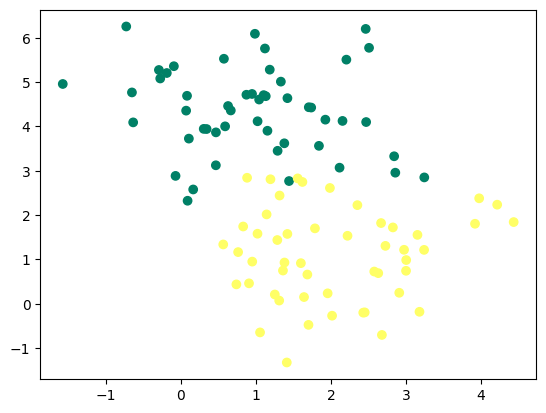

In [349]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [350]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [351]:
W,b = initialisation(X)
print(W.shape)
print(b.shape)


(2, 1)
(1,)


In [352]:
def model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

In [353]:
A = model(X,W,b)
print(A.shape)

(100, 1)


In [354]:
def log_loss(A, y):
    return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

In [355]:
print(log_loss(A,y))

4.5377399429965575


In [356]:
def gradients(A, X, y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [357]:
dw,db = gradients(A,X,y)
print(dw.shape)
print(db.shape)

(2, 1)
()


In [358]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

In [359]:
def predict(X, W, b):
    A = model(X, W, b)
    # print(A)
    return A >= 0.5

In [360]:
from sklearn.metrics import accuracy_score

In [361]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
    # initialisation W, b
    W, b = initialisation(X)

    Loss = []

    for i in range(n_iter):
        A = model(X, W, b)
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)

    y_pred = predict(X, W, b)
    print(accuracy_score(y, y_pred))

    plt.plot(Loss)
    plt.show()

    return (W, b)

0.89


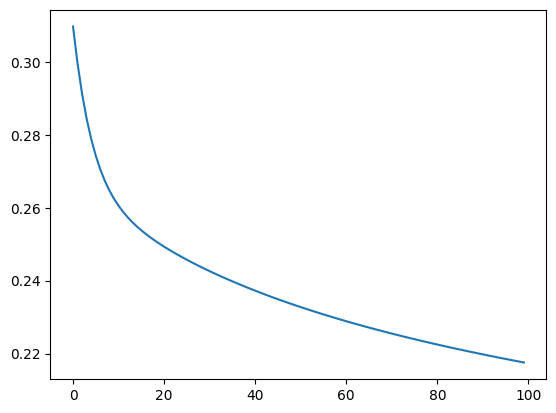

(array([[ 1.24879351],
        [-1.16369734]]),
 array([0.83274357]))

In [362]:
artificial_neuron(X,y)